## 散点图 + 误差棒（误差线）组合图 ，常用于展示不同方法 / 模型在两个评估指标上的表现及结果波动

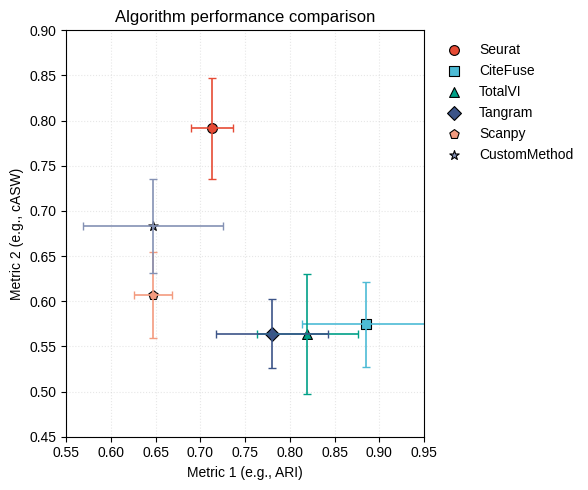

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import rcParams

# 设置Nature期刊风格和Ubuntu兼容字体
# 设置样式
try:
    plt.style.use("scatter.mplstyle")
except:
    pass
# 使用Nature常用的无衬线字体，Ubuntu系统兼容
plt.rcParams["font.sans-serif"] = ["Liberation Sans", "Arial", "Helvetica", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False
# 生成模拟数据（算法评估指标）
np.random.seed(42)

# Algorithm names
algorithms = ["Seurat", "CiteFuse", "TotalVI", "Tangram", "Scanpy", "CustomMethod"]

# Generate evaluation metrics (e.g., ARI and cASW)
data = {
    "Algorithm": algorithms,
    # Metric 1: mean and standard deviation
    "Metric1_mean": np.random.uniform(0.6, 0.9, len(algorithms)),
    "Metric1_error": np.random.uniform(0.02, 0.08, len(algorithms)),
    # Metric 2: mean and standard deviation
    "Metric2_mean": np.random.uniform(0.5, 0.85, len(algorithms)),
    "Metric2_error": np.random.uniform(0.03, 0.09, len(algorithms))
}

df = pd.DataFrame(data)

# Create plot
fig, ax = plt.subplots(figsize=(6, 5))  # Nature常用图大小比例

# Nature风格配色和标记
colors = ["#E64B35", "#4DBBD5", "#00A087", "#3C5488", "#F39B7F", "#8491B4"]
markers = ["o", "s", "^", "D", "p", "*"]

# Plot scatter points and error bars
for i, row in df.iterrows():
    # Scatter plot
    ax.scatter(
        row["Metric1_mean"], row["Metric2_mean"],
        label=row["Algorithm"],
        color=colors[i],
        marker=markers[i],
        s=50,  # 适中的点大小
        edgecolors='black',
        linewidth=0.8
    )
    
    # X error bars
    ax.errorbar(
        row["Metric1_mean"], row["Metric2_mean"],
        xerr=row["Metric1_error"],
        fmt='none',
        ecolor=colors[i],
        elinewidth=1.2,
        capsize=3
    )
    
    # Y error bars
    ax.errorbar(
        row["Metric1_mean"], row["Metric2_mean"],
        yerr=row["Metric2_error"],
        fmt='none',
        ecolor=colors[i],
        elinewidth=1.2,
        capsize=3
    )

# Axis labels and title
ax.set_xlabel("Metric 1 (e.g., ARI)")
ax.set_ylabel("Metric 2 (e.g., cASW)")
ax.set_title("Algorithm performance comparison")

# Axis limits with subtle padding
ax.set_xlim(0.55, 0.95)
ax.set_ylim(0.45, 0.9)

# Add grid with low opacity (Nature风格轻量网格)
ax.grid(True, linestyle=':', alpha=0.3)

# Legend placement
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)

# Tight layout for publication
plt.tight_layout()

# Show plot
plt.show()
# Save with high DPI for publication
# fig.savefig('algorithm_comparison_nature.pdf', dpi=300, bbox_inches='tight')
    